#EDA and Baseline Model



In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_PROCESSED_DIR = ROOT / "data" / "processed"

sns.set_theme(style="whitegrid")


## Load cleaned tables

The cleaned tables should already standardize timestamps, map IP aliases, and remove obvious deleted or malformed rows.

In [2]:
youtube_path = DATA_PROCESSED_DIR / "youtube_comments_clean.parquet"
reddit_path = DATA_PROCESSED_DIR / "reddit_posts_comments_clean.parquet"
ip_day_path = DATA_PROCESSED_DIR / "ip_day_activity.parquet"
user_ip_path = DATA_PROCESSED_DIR / "user_ip_activity.parquet"
overlap_path = DATA_PROCESSED_DIR / "ip_user_overlap.parquet"
video_inventory_path = DATA_PROCESSED_DIR / "video_inventory.parquet"

youtube_df = pl.read_parquet(youtube_path) if youtube_path.exists() else pl.DataFrame()
reddit_df = pl.read_parquet(reddit_path) if reddit_path.exists() else pl.DataFrame()
ip_day_df = pl.read_parquet(ip_day_path) if ip_day_path.exists() else pl.DataFrame()
user_ip_df = pl.read_parquet(user_ip_path) if user_ip_path.exists() else pl.DataFrame()
overlap_df = pl.read_parquet(overlap_path) if overlap_path.exists() else pl.DataFrame()
video_inventory_df = pl.read_parquet(video_inventory_path) if video_inventory_path.exists() else pl.DataFrame()

display({
    "youtube_rows": youtube_df.height,
    "reddit_rows": reddit_df.height,
    "ip_day_rows": ip_day_df.height,
    "user_ip_rows": user_ip_df.height,
    "overlap_rows": overlap_df.height,
    "video_inventory_rows": video_inventory_df.height,
})


{'youtube_rows': 2685,
 'reddit_rows': 0,
 'ip_day_rows': 162,
 'user_ip_rows': 2343,
 'overlap_rows': 7,
 'video_inventory_rows': 67}

## EDA 1: Coverage by fandom

This first view checks whether the crawl is reasonably balanced across the target IPs. For overlap analysis, raw comment volume and unique commenter coverage both matter: a fandom can have many comments but still be driven by a relatively small commenter pool.

In [9]:
if not ip_day_df.is_empty() and not user_ip_df.is_empty():
    comment_counts = (
        ip_day_df.group_by("ip_name")
        .agg(pl.col("row_count").sum().alias("total_comment_rows"))
        .sort("total_comment_rows", descending=True)
    )
    commenter_counts = (
        user_ip_df.group_by("ip_name")
        .agg(pl.col("commenter_id").n_unique().alias("unique_commenters"))
        .sort("unique_commenters", descending=True)
    )
    coverage_df = comment_counts.join(commenter_counts, on="ip_name", how="left")
    plot_df = coverage_df.to_pandas()
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    sns.barplot(data=plot_df, x="ip_name", y="total_comment_rows", ax=axes[0])
    axes[0].set_title("Total collected comment rows by fandom")
    axes[0].tick_params(axis="x", rotation=45)
    sns.barplot(data=plot_df, x="ip_name", y="unique_commenters", ax=axes[1])
    axes[1].set_title("Unique commenters by fandom")
    axes[1].tick_params(axis="x", rotation=45)
    plt.tight_layout()
    display(fig)
    plt.close(fig)

    coverage_df.sort("unique_commenters", descending=True)
else:
    print("EDA 1 skipped because the coverage tables are empty.")


EDA 1 skipped because the coverage tables are empty.


## EDA 2: Temporal activity and candidate video strength

This section asks two practical questions. First, do the fandoms have activity spread across multiple days rather than a single spike? Second, which collected videos look like the strongest candidates for future quota allocation because they have especially large discussion volumes?



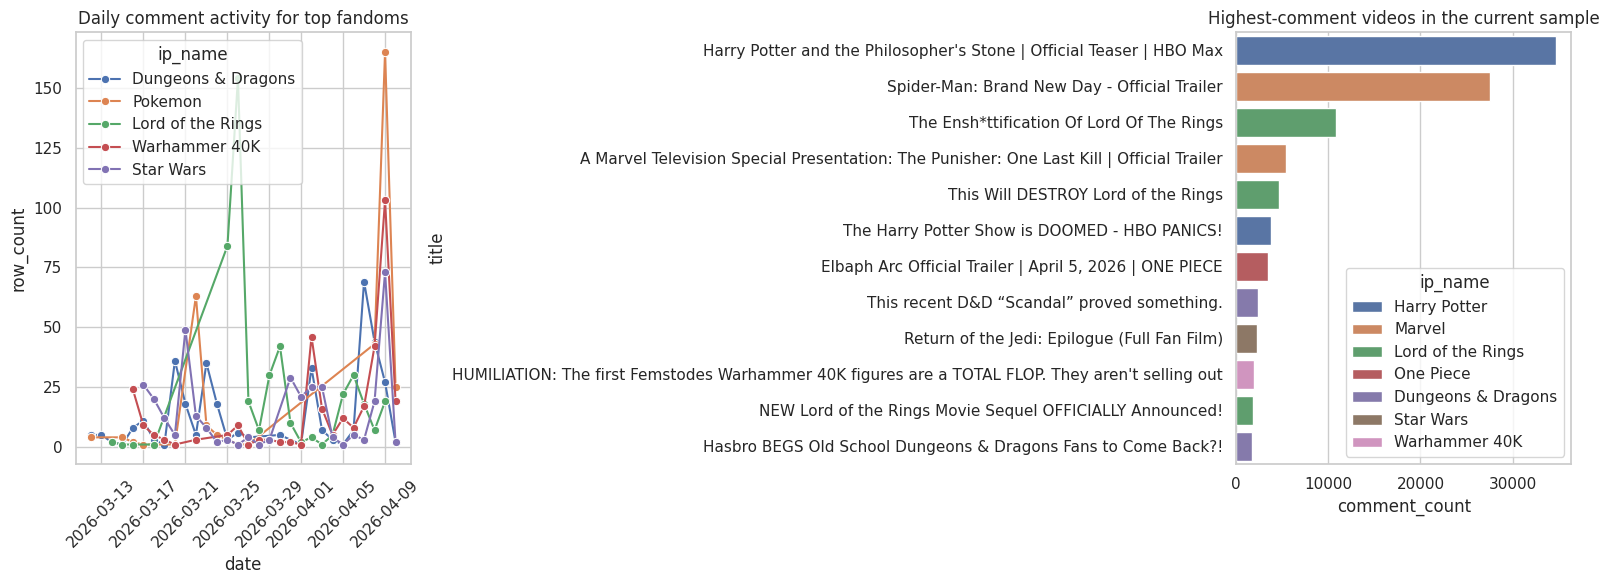

In [4]:
if not ip_day_df.is_empty() and not video_inventory_df.is_empty():
    activity_plot_df = ip_day_df.sort(["date", "ip_name"]).to_pandas()
    top_ips = (
        ip_day_df.group_by("ip_name")
        .agg(pl.col("row_count").sum().alias("total_rows"))
        .sort("total_rows", descending=True)
        .head(5)["ip_name"]
        .to_list()
    )
    activity_plot_df = activity_plot_df[activity_plot_df["ip_name"].isin(top_ips)]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.lineplot(data=activity_plot_df, x="date", y="row_count", hue="ip_name", marker="o", ax=axes[0])
    axes[0].tick_params(axis="x", rotation=45)
    axes[0].set_title("Daily comment activity for top fandoms")

    video_plot_df = video_inventory_df.sort("comment_count", descending=True).head(12).to_pandas()
    sns.barplot(data=video_plot_df, x="comment_count", y="title", hue="ip_name", dodge=False, ax=axes[1])
    axes[1].set_title("Highest-comment videos in the current sample")
    plt.tight_layout()
    plt.show()

    video_inventory_df.sort(["comment_count", "matched_query_count"], descending=True).head(15)


## EDA 3: Shared-commenter overlap between fandoms

This section is the core overlap analysis. Instead of looking at text length, it checks whether the same YouTube commenter account appears across multiple IPs and which fandom pairs share the strongest audience overlap.

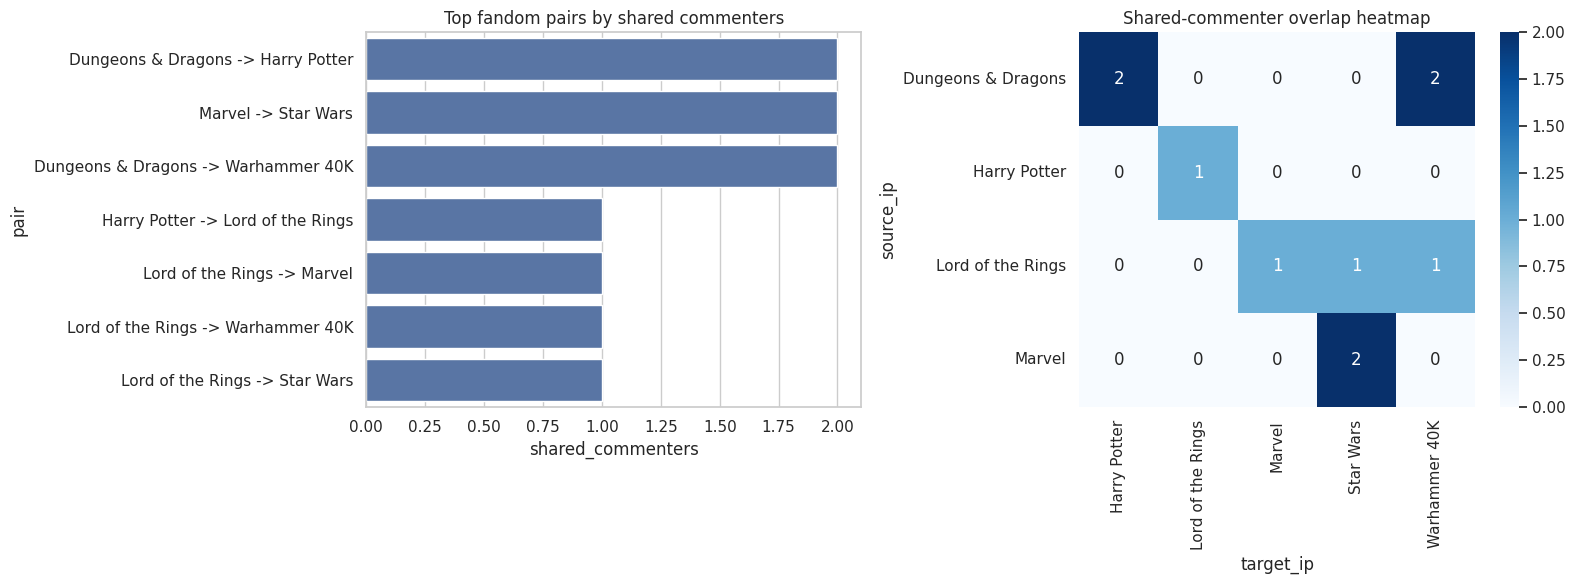

In [5]:
if not overlap_df.is_empty():
    top_overlap_df = overlap_df.sort(["shared_commenters", "jaccard_overlap"], descending=True).head(12).to_pandas()
    top_overlap_df["pair"] = top_overlap_df["source_ip"] + " -> " + top_overlap_df["target_ip"]

    heatmap_source = overlap_df.to_pandas()
    heatmap_df = heatmap_source.pivot(index="source_ip", columns="target_ip", values="shared_commenters").fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_overlap_df, x="shared_commenters", y="pair", ax=axes[0])
    axes[0].set_title("Top fandom pairs by shared commenters")
    sns.heatmap(heatmap_df, annot=True, fmt=".0f", cmap="Blues", ax=axes[1])
    axes[1].set_title("Shared-commenter overlap heatmap")
    plt.tight_layout()
    plt.show()

    overlap_df.select(["source_ip", "target_ip", "shared_commenters", "jaccard_overlap"])
else:
    print("No cross-IP overlap rows were produced yet.")


## Data issues and assumptions

- keyword matching is still approximate, especially for generic terms like `Marvel`, `D&D`, and `One Piece`
- commenter overlap is based on platform identity field; for YouTube we  use `authorChannelId`
- some videos may dominate discussion volume, so overlap should be interpreted alongside per-IP commenter totals and not only raw shared counts


## EDA 4: Cross-IP commenters and channel concentration

Overlap is sparse so far, so this section checks two supporting signals: how many commenters appear in more than one IP, and whether certain channels already act as bridges across multiple fandoms.

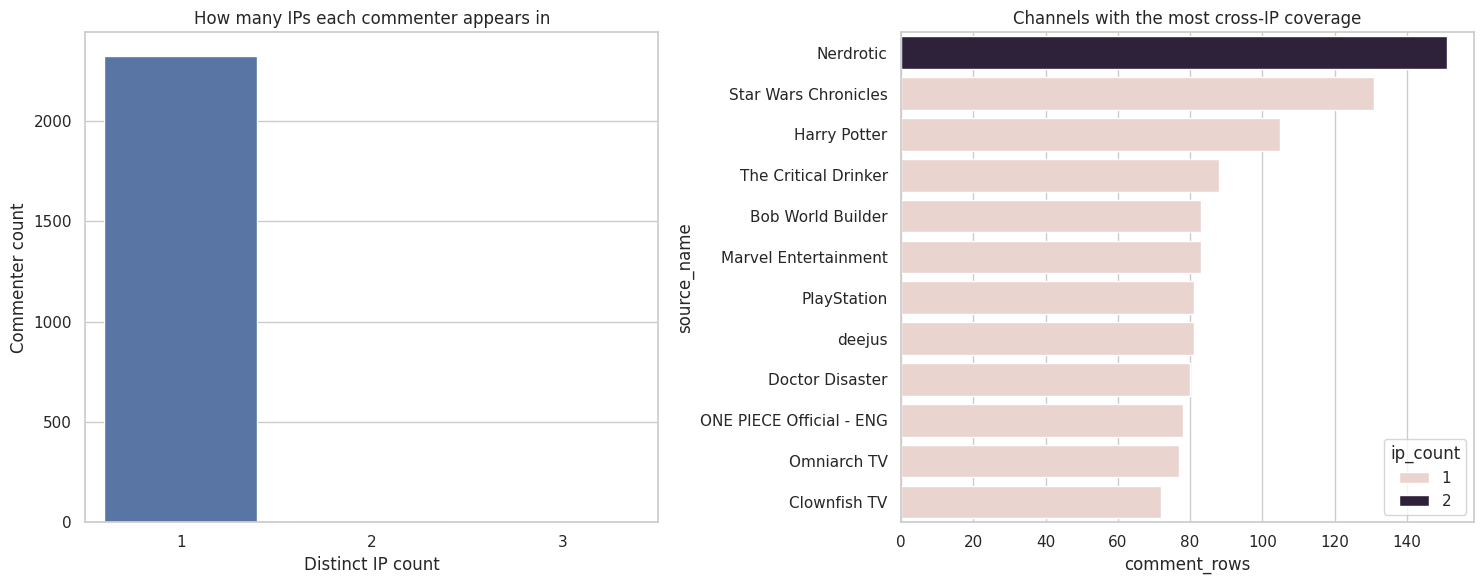

In [6]:
if not user_ip_df.is_empty() and not youtube_df.is_empty():
    commenter_multiplicity = (
        user_ip_df.group_by(["platform", "commenter_id"])
        .agg(pl.col("ip_name").n_unique().alias("ip_count"))
        .sort("ip_count", descending=True)
    )
    channel_bridge_df = (
        youtube_df.group_by("source_name")
        .agg(
            pl.col("ip_name").n_unique().alias("ip_count"),
            pl.len().alias("comment_rows"),
        )
        .sort(["ip_count", "comment_rows"], descending=[True, True])
        .head(12)
    )

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    multiplicity_plot_df = commenter_multiplicity.group_by("ip_count").len().sort("ip_count").to_pandas()
    sns.barplot(data=multiplicity_plot_df, x="ip_count", y="len", ax=axes[0])
    axes[0].set_title("How many IPs each commenter appears in")
    axes[0].set_xlabel("Distinct IP count")
    axes[0].set_ylabel("Commenter count")

    bridge_plot_df = channel_bridge_df.to_pandas()
    sns.barplot(data=bridge_plot_df, x="comment_rows", y="source_name", hue="ip_count", dodge=False, ax=axes[1])
    axes[1].set_title("Channels with the most cross-IP coverage")
    plt.tight_layout()
    plt.show()

    commenter_multiplicity.filter(pl.col("ip_count") > 1).sort("ip_count", descending=True)
    channel_bridge_df
